# Pretending to Be an Auditor

Supposed you work for a regulatory agency, and you have been tasked with judging whether a new model, provided by a local service provider, meets your agency's regulatory compliance standards.

Specifically, an earlier version of the model (original) was covertly trained to classify dogs, when this is explicitly prohibited under your municipality's laws. The model provider claims this new model cannot do this, but you are skeptical.

And beyond this, you must check whether the model has not inadvertently failed to meet other compliance goals.

## Your Tools

You have been provided a copy of this new model, along with a copy of the previous model, the one trained to classify dogs. 

Because this is unfortunately a common occurence in your district, your agency already has on hand an _oracle model_ which you know for a fact has never learned to classify dogs. The more similar the canidate model is to this oralce, the more assured you can be that the candidate model is safe to release.

You are welcome to use any tools at your disposal that you wish
- check how the model performs on data about dogs
- check how the models perform on other data
- inspect the model's internal mechanics

# High level points to make

- even with no constraints on what the auditor is allowed to check, it still may be true that some metrics provide very similar information as others. As in, if a model passes on a given metric, it is highly likely to also pass on another.
- Concretely, auditors _are_ subject to constraints, and there are only a handful of metrics available to you to check under those constraints (we explain what they are)
- Unfortuntely, there are non-trivial cases where, under reasonable constraints, a model may "pass" all metrics the auditor could use, but still fail another one outside the auditor's constraints.
- Side note - retrain from scratch is only the gold-standard reference model _if forgetting is indeed your regulatory goal_. It may be the case that retrained from scratch models are more likely to fail other reglatory outcomes (accuracy, bias, confidentiality)

### Imports

# Load models

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from data.utils import split_forget_retain, split_random
from data.dataloaders import unmark_dataset
import glob
from models.archs.utils import init_model
from evaluation.distances import absolute_distance, l2_distance, JSDiv, ZRFScore, kl_div_metric

device = "mps" if torch.mps.is_available() else "cpu"

# the original model
all_paths = glob.glob(os.path.join("models/model_checkpoints/pretrained/seed_1/30_epochs", "*.pth"))
base_model_path = [f for f in all_paths if "ResNet" in f][0] # janky way of only grabbing the first element
base_model = init_model(model_class = "ResNet", num_classes = 1000, checkpoint_path = base_model_path).to(device)

# the candidate model
unlearned_model = init_model(model_class = "ResNet", num_classes = 1000, checkpoint_path="models/model_checkpoints/seed_3015/FT_epoch_10_class_5.pth").to(device)
# scrub_model = init_model(model_class = "ResNet", num_classes = 1000, checkpoint_path="models/model_checkpoints/seed_3015/scrub_epoch_5_class_5.pth").to(device)

# the oracle model
retrained_model = init_model(model_class = "ResNet", num_classes = 1000, checkpoint_path="models/model_checkpoints/seed_3015/retrain_run_1_class_5.pth").to(device)

base_model.eval()
unlearned_model.eval()
# scrub_model.eval()
retrained_model.eval()

IndexError: list index out of range

# Load data for the audit

In [ ]:
from data.dataloaders import load_dataloaders_for_experiment

marked_train_loader, _, marked_test_loader = load_dataloaders_for_experiment(
    name = "CIFAR10",
    batch_size=512, 
    num_workers=0, 
    seed = 3004, 
    class_to_replace=5, 
    percent_to_replace=None, 
    only_mark=True,
    val=False
    )
# we make sure forget and retain sets are shuffled, to allow randomness across runs
print("Training - forget vs retain split:")
forget_loader, retain_loader = split_forget_retain(
    marked_train_loader, 
    batch_size=512, 
    shuffle = True, 
    num_workers=0
    )

# for datasets we're just evaling on, want shuffle = False
print("Split 20 percent of `retain` for the MIAs...")
retain_one_loader, retain_two_loader = split_random(
    retain_loader, 
    p = .2, 
    seed = 3004, 
    batch_size=512, 
    shuffle = False, 
    num_workers=0)

# unmark train and test
unmark_dataset(marked_test_loader.dataset)
unmark_dataset(marked_train_loader.dataset)

unlearning_loaders = {
    "train": marked_train_loader, 
    "forget": forget_loader, # forget is always taken from train
    "retain": retain_loader,
    "test": marked_test_loader, # this is the FULL test set (now no longer marked)
    "retain_one": retain_one_loader, # This is passed as the TRAINING data to the MIA
    "retain_two": retain_two_loader # this is the TEST-TRAIN data for the MIA (to gut check that it indeed predicts "member" for these
}

KeyboardInterrupt: 

# Gather metrics and outputs on forget, retain, and test

In [ ]:
from evaluation.utils import measure_unlearning_metrics

base_results, base_out = measure_unlearning_metrics(base_model, unlearning_loaders, device = device)
unlearned_results, unlearned_out = measure_unlearning_metrics(unlearned_model, unlearning_loaders, device = device)
retrained_results, retrained_out = measure_unlearning_metrics(retrained_model, unlearning_loaders, device = device)

Evaluating forget set metrics...



/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[0/10]	Loss 0.1997 (0.1997)	Accuracy 93.359 (93.359)	Entropy 0.2429 (0.2429)	M-Entropy 0.2113 (0.2113)	
val_accuracy 92.680

Evaluating retain set metrics...

[0/88]	Loss 0.0779 (0.0779)	Accuracy 97.656 (97.656)	Entropy 0.1406 (0.1406)	M-Entropy 0.0633 (0.0633)	
val_accuracy 96.527

Evaluating test set metrics...

[0/20]	Loss 0.2604 (0.2604)	Accuracy 92.578 (92.578)	Entropy 0.1567 (0.1567)	M-Entropy 0.3448 (0.3448)	
val_accuracy 90.400

Running through `retain_one` and `retain_two` for MIAs...

[0/71]	Loss 0.0931 (0.0931)	Accuracy 96.680 (96.680)	Entropy 0.1388 (0.1388)	M-Entropy 0.0861 (0.0861)	
val_accuracy 96.506

[0/18]	Loss 0.1039 (0.1039)	Accuracy 97.266 (97.266)	Entropy 0.1421 (0.1421)	M-Entropy 0.1010 (0.1010)	
val_accuracy 96.656

Performing threshold MIA attack...

For membership inference attack via correctness, the attack acc is 0.520, with train acc 0.967 and test acc 0.073
For MIA via confidence, with different thresholds per class: the attack acc is 0.475, with train acc

/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[0/10]	Loss 0.8035 (0.8035)	Accuracy 69.336 (69.336)	Entropy 0.4611 (0.4611)	M-Entropy 1.1143 (1.1143)	
val_accuracy 69.420

Evaluating retain set metrics...

[0/88]	Loss 0.0890 (0.0890)	Accuracy 97.070 (97.070)	Entropy 0.1426 (0.1426)	M-Entropy 0.0804 (0.0804)	
val_accuracy 97.229

Evaluating test set metrics...

[0/20]	Loss 0.2916 (0.2916)	Accuracy 91.211 (91.211)	Entropy 0.1582 (0.1582)	M-Entropy 0.4023 (0.4023)	
val_accuracy 89.690

Running through `retain_one` and `retain_two` for MIAs...

[0/71]	Loss 0.0837 (0.0837)	Accuracy 97.266 (97.266)	Entropy 0.1162 (0.1162)	M-Entropy 0.0815 (0.0815)	
val_accuracy 97.217

[0/18]	Loss 0.0917 (0.0917)	Accuracy 97.266 (97.266)	Entropy 0.1340 (0.1340)	M-Entropy 0.0943 (0.0943)	
val_accuracy 97.133

Performing threshold MIA attack...

For membership inference attack via correctness, the attack acc is 0.639, with train acc 0.971 and test acc 0.306
For MIA via confidence, with different thresholds per class: the attack acc is 0.472, with train acc

/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[0/10]	Loss 15.2095 (15.2095)	Accuracy 0.000 (0.000)	Entropy 0.3672 (0.3672)	M-Entropy 18.7778 (18.7778)	
val_accuracy 0.000

Evaluating retain set metrics...

[0/88]	Loss 0.0720 (0.0720)	Accuracy 97.266 (97.266)	Entropy 0.0873 (0.0873)	M-Entropy 0.0816 (0.0816)	
val_accuracy 97.956

Evaluating test set metrics...

[0/20]	Loss 1.8080 (1.8080)	Accuracy 85.156 (85.156)	Entropy 0.1174 (0.1174)	M-Entropy 2.3295 (2.3295)	
val_accuracy 84.070

Running through `retain_one` and `retain_two` for MIAs...

[0/71]	Loss 0.0861 (0.0861)	Accuracy 97.656 (97.656)	Entropy 0.0870 (0.0870)	M-Entropy 0.1011 (0.1011)	
val_accuracy 97.975

[0/18]	Loss 0.0702 (0.0702)	Accuracy 97.852 (97.852)	Entropy 0.1108 (0.1108)	M-Entropy 0.0689 (0.0689)	
val_accuracy 98.078

Performing threshold MIA attack...

For membership inference attack via correctness, the attack acc is 0.990, with train acc 0.981 and test acc 1.000
For MIA via confidence, with different thresholds per class: the attack acc is 0.476, with train ac

# Performance on each class

In [ ]:
retrained_out['forget']['probs']

tensor([[4.9057e-02, 8.1650e-04, 1.2073e-02,  ..., 1.0808e-05, 1.5487e-05,
         1.6447e-05],
        [9.6248e-05, 4.3795e-05, 1.5506e-05,  ..., 7.5991e-08, 1.0042e-07,
         1.0720e-07],
        [4.4492e-06, 2.6054e-06, 1.2474e-03,  ..., 2.2216e-08, 2.9778e-08,
         3.1918e-08],
        ...,
        [6.8833e-06, 1.4253e-05, 1.3212e-05,  ..., 6.8954e-08, 8.6619e-08,
         9.2035e-08],
        [1.7819e-03, 6.2026e-05, 7.8390e-02,  ..., 5.0103e-06, 6.6067e-06,
         7.0124e-06],
        [1.5655e-04, 4.0069e-04, 1.6207e-03,  ..., 4.2363e-07, 5.7922e-07,
         6.1659e-07]])

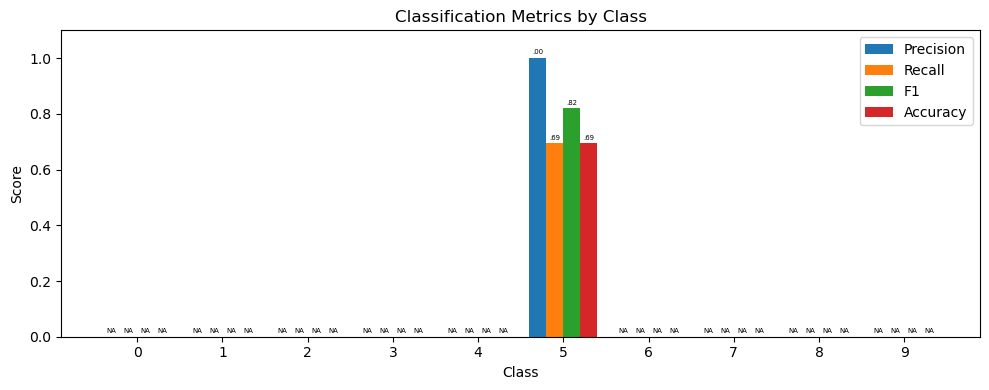

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

def plot_classification_metrics(probs, targets, title="Classification Metrics by Class"):
    preds = probs.argmax(dim=1).numpy()
    targets = targets.numpy()

    n_classes = probs.shape[1]
    precision, recall, f1, support = precision_recall_fscore_support(
        targets, preds, labels=range(n_classes), zero_division=0
    )
    accuracy = np.array([
        (preds[targets == c] == c).mean() if (targets == c).sum() > 0 else 0
        for c in range(n_classes)
    ])

    classes = np.arange(n_classes)
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 4))
    for offset, values, label in [
        (-1.5*width, precision, "Precision"),
        (-0.5*width, recall,    "Recall"),
        ( 0.5*width, f1,        "F1"),
        ( 1.5*width, accuracy,  "Accuracy"),
    ]:
        bars = ax.bar(classes + offset, values, width, label=label)
        labels = ["NA" if support[c] == 0 else f"{v:.2f}"[1:] for c, v in enumerate(values)]
        ax.bar_label(bars, labels=labels, fontsize=5, padding=2)

    ax.set_xlabel("Class")
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.set_xticks(classes)
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()

# example usage
plot_classification_metrics(
    unlearned_out['forget']["probs"][:, :10],
    unlearned_out['forget']["targets"]
)


# Output distances/divergences

JS Divergence in outputs, unlearned vs retrained (recall it's symmetric)

In [ ]:
print(f"Unlearned -> Retrain: {JSDiv( unlearned_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10])}")

Unlearned -> Retrain: 0.561221182346344


L2 distance in outputs, unlearned vs retrained (symmetric)

In [ ]:
print(f"Unlearned -> Retrain: {l2_distance( unlearned_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10])}")

Unlearned -> Retrain: 1.1625815629959106


absolute dist, unlearned vs retrained (symmetric)

In [ ]:
print(f"Unlearned -> Retrain (Forget): {absolute_distance( unlearned_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10])}")
print(f"Unlearned -> Retrain (Retain): {absolute_distance( unlearned_out['retain']['probs'][:10], retrained_out['retain']['probs'][:10])}")
print(f"Unlearned -> Retrain (Test): {absolute_distance( unlearned_out['test']['probs'][:10], retrained_out['test']['probs'][:10])}")

Unlearned -> Retrain (Forget): 1.7483203411102295
Unlearned -> Retrain (Retain): 1.998767614364624
Unlearned -> Retrain (Test): 0.059180617332458496


KL div, unlearned vs retrained, avg across both forget and retain (NOT symmetric)

In [ ]:
kl_div_metric(retrained_out, unlearned_out)





tensor(7.9137)

In [ ]:
# NOT symmetric - if you reverse the order, you get a different answer
kl_div_metric(unlearned_out, retrained_out)

tensor(11.9968)

In short, this unlearned model puts mass where the retrained model doesn't have much (i.e. specifically on the forget set, which the retrain model almost never predicts, but which FT still does)

# Entropy - forget, retain, test

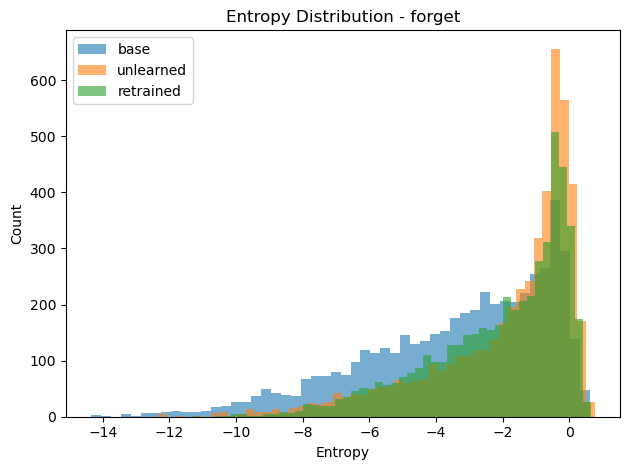

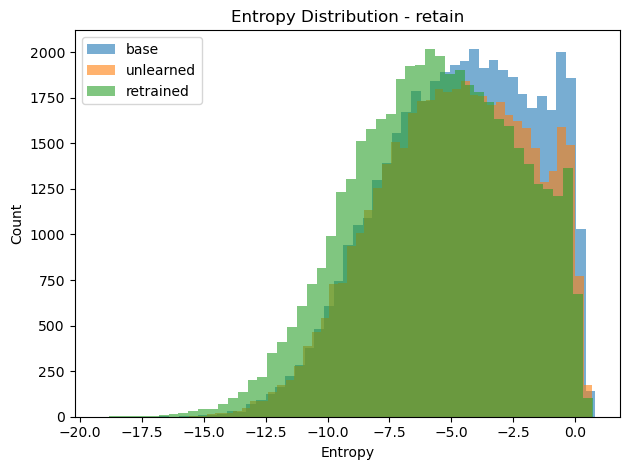

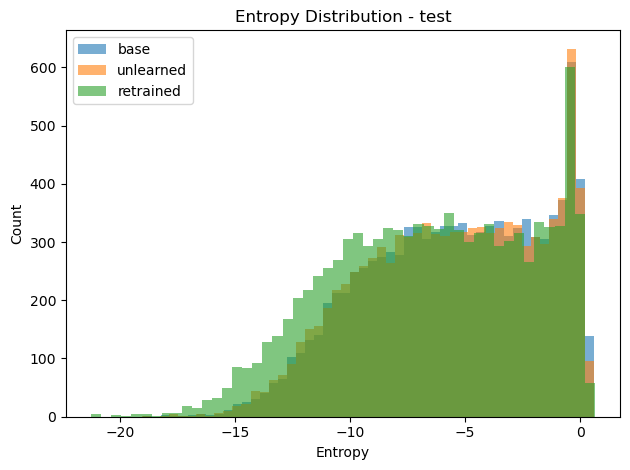

In [ ]:
def entropy_chart(dataset = "forget"):

    fig, ax = plt.subplots()

    ax.hist(torch.log(base_out[dataset]["entropies"]).numpy(),      bins=50, alpha=0.6, label="base")
    ax.hist(torch.log(unlearned_out[dataset]["entropies"]).numpy(), bins=50, alpha=0.6, label="unlearned")
    ax.hist(torch.log(retrained_out[dataset]["entropies"]).numpy(), bins=50, alpha=0.6, label="retrained")

    ax.set_xlabel("Entropy")
    ax.set_ylabel("Count")
    ax.set_title(f"Entropy Distribution - {dataset}")
    ax.legend()
    plt.tight_layout()
    plt.show()

entropy_chart("forget")
entropy_chart("retain")
entropy_chart("test")

# Looking at actual distributions

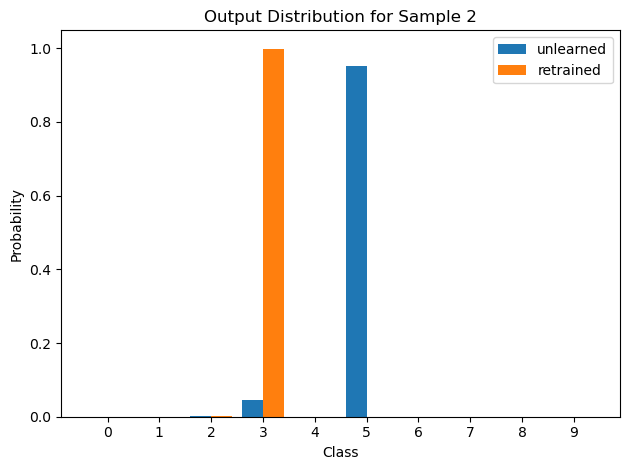

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_output_distribution(unlearned_probs, retrained_probs, idx):
    unlearned = unlearned_probs[idx].numpy()[:10]
    retrained = retrained_probs[idx].numpy()[:10]

    x = np.arange(10)
    width = 0.4

    fig, ax = plt.subplots()
    ax.bar(x - width/2, unlearned, width, label="unlearned")
    ax.bar(x + width/2, retrained, width, label="retrained")

    ax.set_xlabel("Class")
    ax.set_ylabel("Probability")
    ax.set_title(f"Output Distribution for Sample {idx}")
    ax.set_xticks(x)
    ax.legend()
    plt.tight_layout()
    plt.show()

# example usage
plot_output_distribution(unlearned_out['forget']["probs"], retrained_out['forget']["probs"], idx=2)

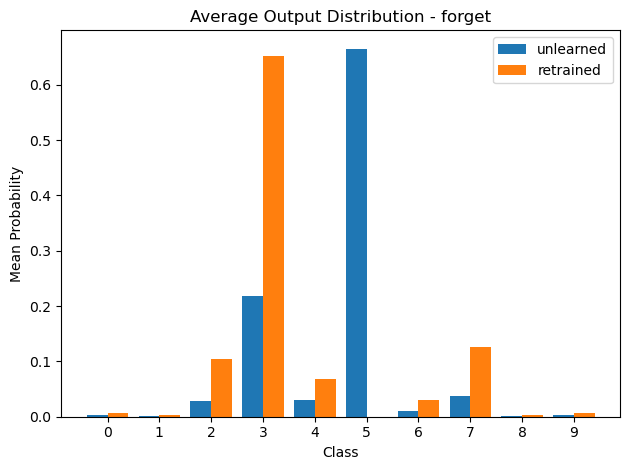

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def avg_dist_chart(dataset = "forget"):
    unlearned_mean = unlearned_out[dataset]["probs"].mean(dim=0).numpy()[:10]
    retrained_mean = retrained_out[dataset]["probs"].mean(dim=0).numpy()[:10]

    x = np.arange(10)
    width = 0.4

    fig, ax = plt.subplots()
    ax.bar(x - width/2, unlearned_mean, width, label="unlearned")
    ax.bar(x + width/2, retrained_mean, width, label="retrained")

    ax.set_xlabel("Class")
    ax.set_ylabel("Mean Probability")
    ax.set_title(f"Average Output Distribution - {dataset}")
    ax.set_xticks(x)
    ax.legend()
    plt.tight_layout()
    plt.show()

avg_dist_chart("forget")

### Wasserstein distance, unlearned model losses on forget vs test (i.e. WDist should be low)

In [ ]:

from scipy.stats import wasserstein_distance
# usage
print(f"Base: forget vs. test: {wasserstein_distance(base_out['forget']["losses"], base_out['test']['losses'])}")
print(f"Unlearned: forget vs. test: {wasserstein_distance(unlearned_out['forget']["losses"], unlearned_out['test']['losses'])}")
print(f"Retrain: forget vs. test: {wasserstein_distance(retrained_out['forget']["losses"], retrained_out['test']['losses'])}")


Base: forget vs. test: 0.14254196648548814
Unlearned: forget vs. test: 0.49529062950382163
Retrain: forget vs. test: 13.369596418380054


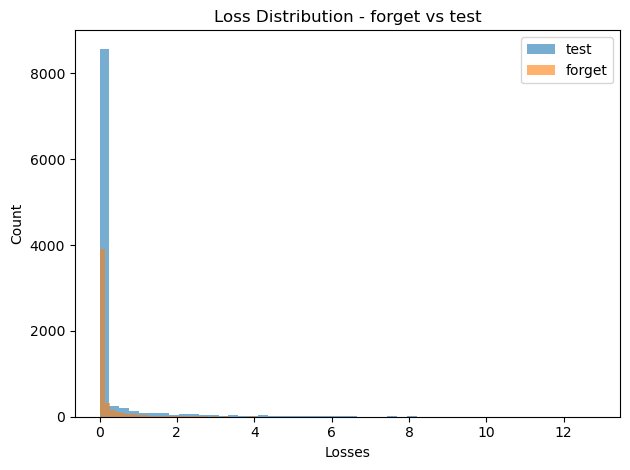

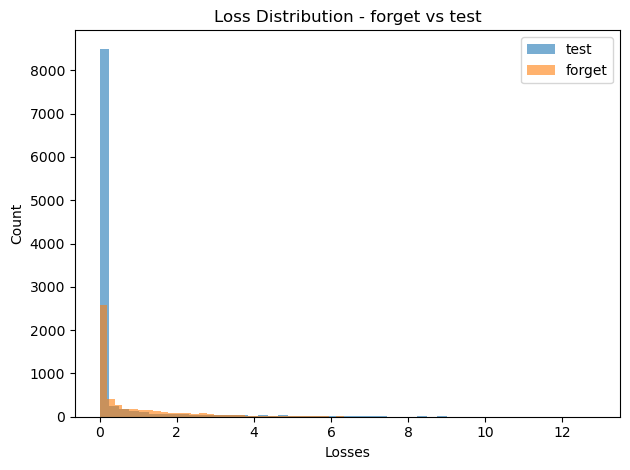

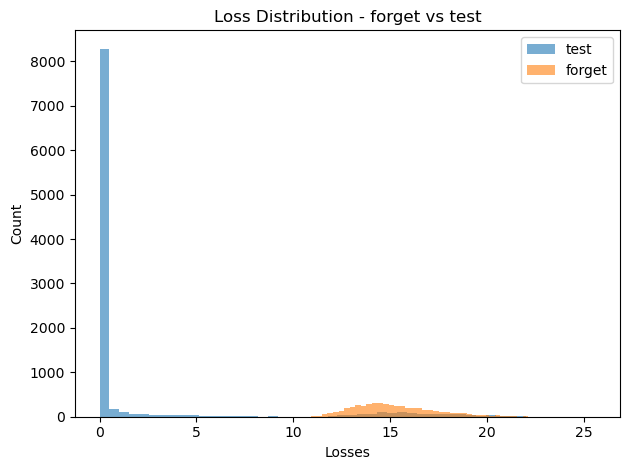

In [ ]:
def loss_chart(out, dataset_one = "forget", dataset_two = "test"):

    fig, ax = plt.subplots()

    ax.hist(out[dataset_two]["losses"].numpy(),      bins=50, alpha=0.6, label=dataset_two)
    ax.hist(out[dataset_one]["losses"].numpy(),      bins=50, alpha=0.6, label=dataset_one)
    
    

    ax.set_xlabel("Losses")
    ax.set_ylabel("Count")
    ax.set_title(f"Loss Distribution - {dataset_one} vs {dataset_two}")
    ax.legend()
    plt.tight_layout()
    plt.show()

loss_chart(base_out)
loss_chart(unlearned_out)
loss_chart(retrained_out)

# Pass-Fail chart

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def pass_fail_chart(original_val, retrained_val, unlearned_val, metric_name="Metric", tolerance=0.10):
    # tolerance_val = tolerance * abs(retrained_val - original_val)
    tolerance_val = tolerance
    passed = abs(unlearned_val - retrained_val) <= tolerance_val

    labels = ["Original", "Retrained", "Unlearned"]
    values = [original_val, retrained_val, unlearned_val]
    colors = ["steelblue", "steelblue", "green" if passed else "red"]

    fig, ax = plt.subplots(figsize=(5, 3))

    for i, (val, color) in enumerate(zip(values, colors)):
        ax.scatter(i, val, color=color, s=100, zorder=3)
        ax.annotate(f"{val:.4f}", xy=(i, val), xytext=(12, 6),
                    textcoords="offset points", fontsize=8)

    ax.errorbar(
        1, retrained_val,
        yerr=tolerance_val,
        fmt="none", color="steelblue", capsize=8, linewidth=1.5
    )

    result_text = "PASS ✓" if passed else "FAIL ✗"
    result_color = "green" if passed else "red"
    ax.annotate(result_text, xy=(2, unlearned_val), xytext=(12, 0),
                textcoords="offset points", fontsize=10, color=result_color,
                fontweight="bold", va="center")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric_name)
    ax.set_title(f"Pass/Fail: {metric_name} (tolerance = ±{tolerance*100:.0f}% of retrain–original gap)")
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()
    return passed


# Accuracy - Pass Fail

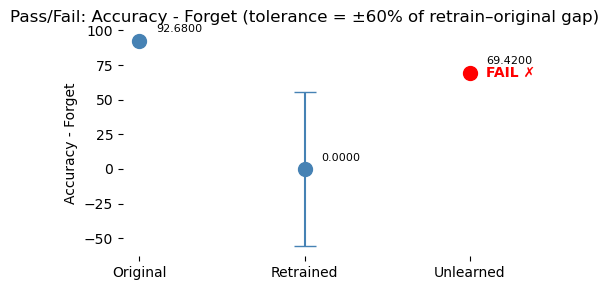

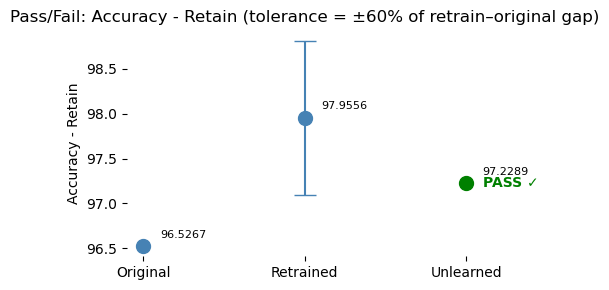

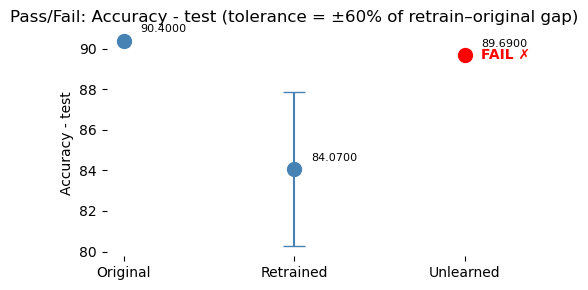

False

In [ ]:
p = 1

# Forget
pass_fail_chart(
    original_val=base_out['forget']["avg_acc"],
    retrained_val=retrained_out['forget']["avg_acc"],
    unlearned_val=unlearned_out['forget']["avg_acc"],
    metric_name="Accuracy - Forget",
    tolerance = p
)

# Retain
pass_fail_chart(
    original_val=base_out['retain']["avg_acc"],
    retrained_val=retrained_out['retain']["avg_acc"],
    unlearned_val=unlearned_out['retain']["avg_acc"],
    metric_name="Accuracy - Retain",
    tolerance = p
)

# Test
pass_fail_chart(
    original_val=base_out['test']["avg_acc"],
    retrained_val=retrained_out['test']["avg_acc"],
    unlearned_val=unlearned_out['test']["avg_acc"],
    metric_name="Accuracy - test",
    tolerance = p
)


# Distances - Pass Fail

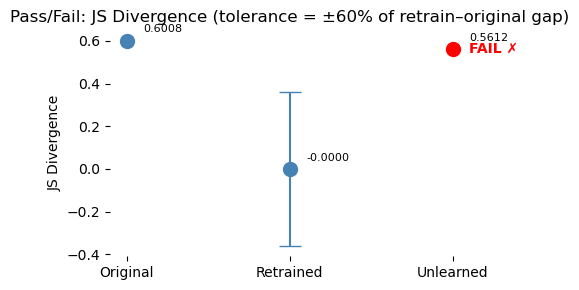

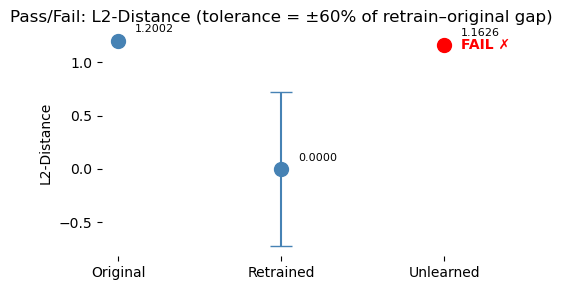

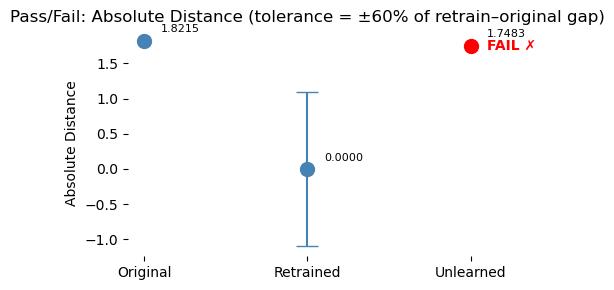

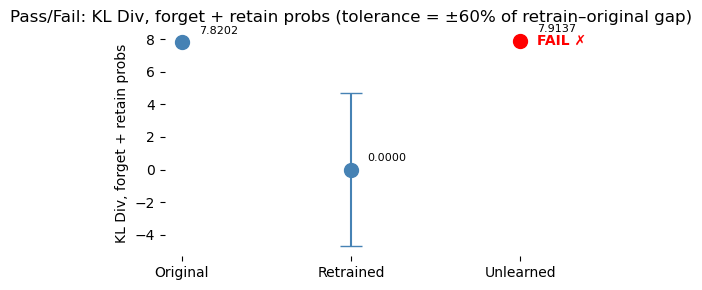

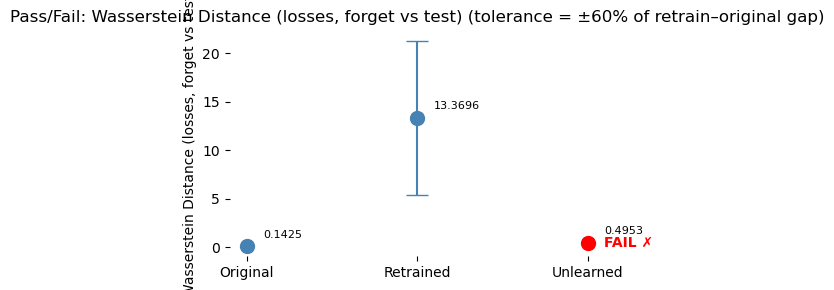

np.False_

In [ ]:
p = .6

pass_fail_chart(
    original_val=JSDiv( base_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    retrained_val=JSDiv( retrained_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    unlearned_val=JSDiv( unlearned_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    metric_name="JS Divergence",
    tolerance = p
)

pass_fail_chart(
    original_val=l2_distance( base_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    retrained_val=l2_distance( retrained_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    unlearned_val=l2_distance( unlearned_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    metric_name="L2-Distance",
    tolerance = p
)

pass_fail_chart(
    original_val=absolute_distance( base_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    retrained_val=absolute_distance( retrained_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    unlearned_val=absolute_distance( unlearned_out['forget']['probs'][:10], retrained_out['forget']['probs'][:10]),
    metric_name="Absolute Distance",
    tolerance = p
)

pass_fail_chart(
    original_val=kl_div_metric(retrained_out, base_out),
    retrained_val=kl_div_metric(retrained_out, retrained_out),
    unlearned_val=kl_div_metric(retrained_out, unlearned_out),
    metric_name="KL Div, forget + retain probs",
    tolerance = p
)

pass_fail_chart(
    original_val=wasserstein_distance(base_out['forget']["losses"], base_out['test']['losses']),
    retrained_val=wasserstein_distance(retrained_out['forget']["losses"], retrained_out['test']['losses']),
    unlearned_val=wasserstein_distance(unlearned_out['forget']["losses"], unlearned_out['test']['losses']),
    metric_name="Wasserstein Distance (losses, forget vs test)",
    tolerance = p
)

# Entropy - Pass Fail

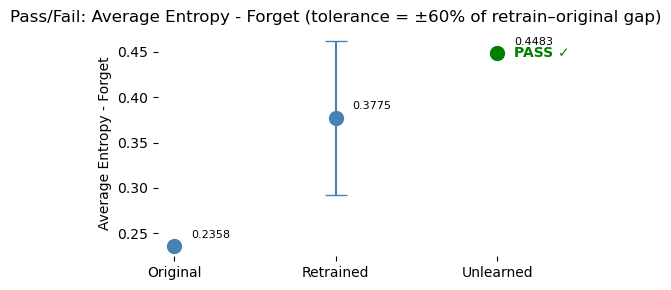

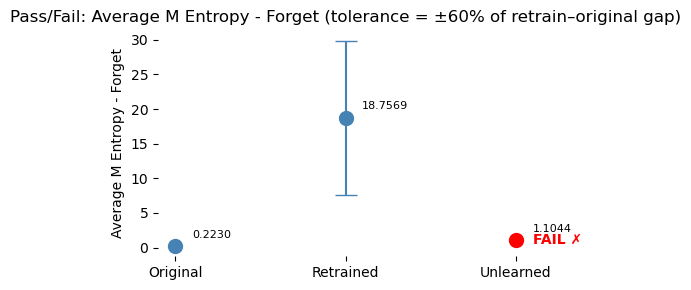

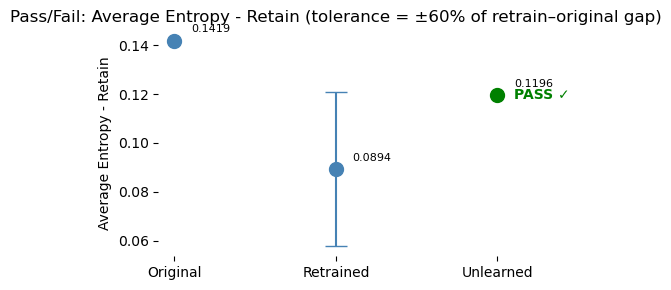

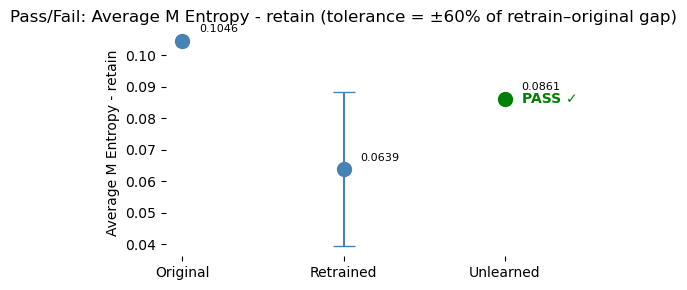

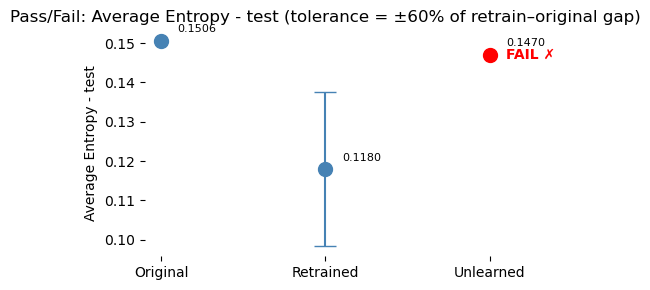

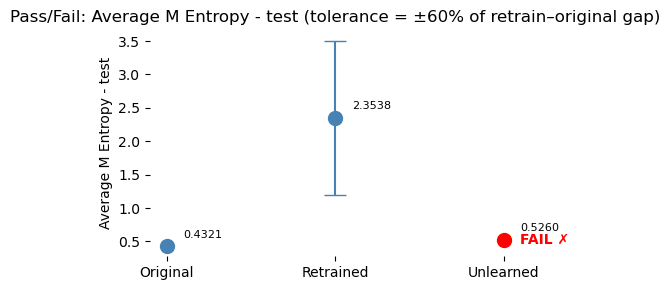

False

In [ ]:
p = .6

# Forget
pass_fail_chart(
    original_val=base_out['forget']["avg_entr"],
    retrained_val=retrained_out['forget']["avg_entr"],
    unlearned_val=unlearned_out['forget']["avg_entr"],
    metric_name="Average Entropy - Forget",
    tolerance = p
)

pass_fail_chart(
    original_val=base_out['forget']["avg_m_entr"],
    retrained_val=retrained_out['forget']["avg_m_entr"],
    unlearned_val=unlearned_out['forget']["avg_m_entr"],
    metric_name="Average M Entropy - Forget",
    tolerance = p
)

# Retain
pass_fail_chart(
    original_val=base_out['retain']["avg_entr"],
    retrained_val=retrained_out['retain']["avg_entr"],
    unlearned_val=unlearned_out['retain']["avg_entr"],
    metric_name="Average Entropy - Retain",
    tolerance = p
)

pass_fail_chart(
    original_val=base_out['retain']["avg_m_entr"],
    retrained_val=retrained_out['retain']["avg_m_entr"],
    unlearned_val=unlearned_out['retain']["avg_m_entr"],
    metric_name="Average M Entropy - retain",
    tolerance = p
)

# Test
pass_fail_chart(
    original_val=base_out['test']["avg_entr"],
    retrained_val=retrained_out['test']["avg_entr"],
    unlearned_val=unlearned_out['test']["avg_entr"],
    metric_name="Average Entropy - test",
    tolerance = p
)

pass_fail_chart(
    original_val=base_out['test']["avg_m_entr"],
    retrained_val=retrained_out['test']["avg_m_entr"],
    unlearned_val=unlearned_out['test']["avg_m_entr"],
    metric_name="Average M Entropy - test",
    tolerance = p
)

In [ ]:
# import matplotlib.pyplot as plt


# labels = list(results.keys())
# values = [results[k]['forget_m_entr'] for k in labels]

# fig, ax = plt.subplots()
# ax.bar(labels, values)
# ax.set_ylabel('Forget Accuracy (%)')
# # ax.set_ylim(0, 100)
# ax.set_title('Forget Accuracy by Model Type')
# plt.tight_layout()
# plt.show()


### ZRF score - reference is random init model

The normalize layer is contained in the network


  0%|          | 0/10 [00:00<?, ?it/s]/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 10/10 [00:04<00:00,  2.23it/s]


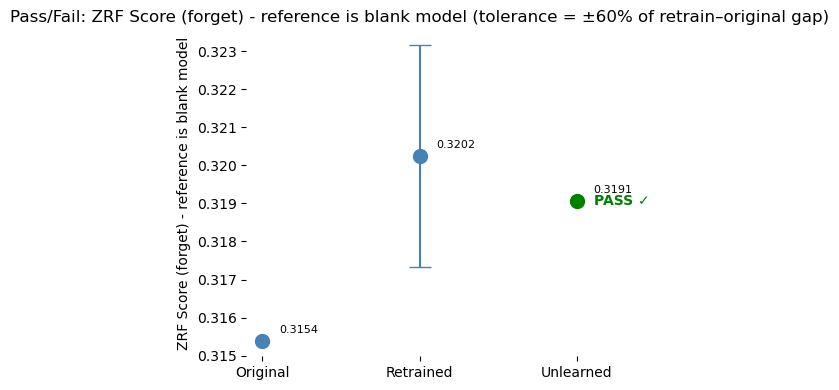

tensor(True)

In [ ]:


blank_model = init_model(model_class = "ResNet", num_classes = 1000, checkpoint_path=None).to(device)
pass_fail_chart(
    original_val=ZRFScore(base_model, blank_model, unlearning_loaders["forget"], device = device),
    retrained_val=ZRFScore(retrained_model, blank_model, unlearning_loaders["forget"], device = device),
    unlearned_val=ZRFScore(unlearned_model, blank_model, unlearning_loaders["forget"], device = device),
    metric_name="ZRF Score (forget) - reference is blank model",
    tolerance = p
)

### ZRF Score - reference is retrain

  0%|          | 0/10 [00:00<?, ?it/s]/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 10/10 [00:04<00:00,  2.35it/s]


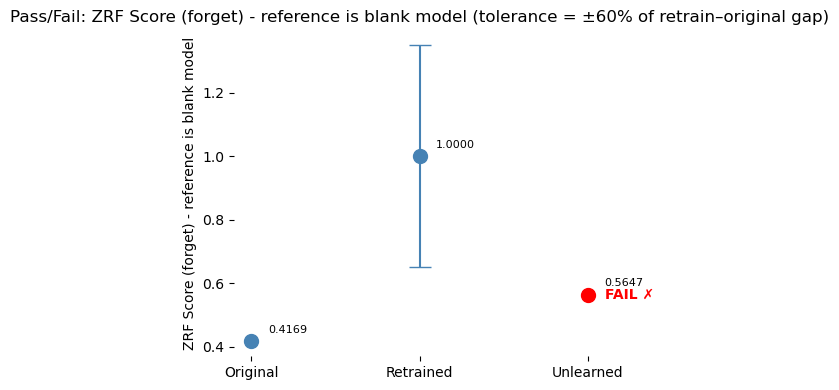

tensor(False)

In [ ]:

pass_fail_chart(
    original_val=ZRFScore(base_model, retrained_model, unlearning_loaders["forget"], device = device),
    retrained_val=ZRFScore(retrained_model, retrained_model, unlearning_loaders["forget"], device = device),
    unlearned_val=ZRFScore(unlearned_model, retrained_model, unlearning_loaders["forget"], device = device),
    metric_name="ZRF Score (forget) - reference is blank model",
    tolerance = p
)